# ML Model for Churn Prediction

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42

DATA_PATH = Path("../data/processed")
OUT_DIR = Path("../outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load processed data

Paths are relative to project root (found via `pyproject.toml` / `environment.yml`), so the notebook works from any cwd. Run `00_project_setup.ipynb` first so that `data/processed/churn_features.csv` exists.

In [4]:
FEATURES_CSV = DATA_PATH / "churn_features.csv"
if not FEATURES_CSV.exists():
    raise FileNotFoundError(
        f"Processed data not found at {FEATURES_CSV}. "
        "Run notebooks/00_project_setup.ipynb first to generate it."
    )
df = pd.read_csv(FEATURES_CSV)
print(df.shape)
df.head()

(98096, 8)


,customer_id,recency,tenure_days,frequency,monetary,avg_review,churn,source
0,0000366f3b9a7992bf8c76cfdf3221e2,160,160,1,141.90,5.0,1,Olist
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,163,1,27.19,4.0,1,Olist
2,0000f46a3911fa3c0805444483337064,585,585,1,86.22,3.0,1,Olist
3,0000f6ccb0745a6a4b88665a16c9f078,369,369,1,43.62,4.0,1,Olist
4,0004aac84e0df4da2b147fca70cf8255,336,336,1,196.89,5.0,1,Olist


## 2. Prepare features and target

Use the same numeric features as in setup (RFM + tenure + avg_review). Exclude `source` for a unified model; optionally train separately per source later.

In [5]:
feature_cols = ["recency", "tenure_days", "frequency", "monetary", "avg_review"]
model_df = df.dropna(subset=feature_cols + ["churn"])
X = model_df[feature_cols]
y = model_df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print("Train:", X_train.shape[0], "Test:", X_test.shape[0], "Churn rate:", y.mean().round(3))

Train: 73572 Test: 24524 Churn rate: 0.897


## 3. Train a model that outputs churn probabilities

We use a classifier with `predict_proba` so we can rank customers by churn probability (for targeting and segmentation). Proposal target: F1 > 0.70.

In [6]:
# Scale features for LogisticRegression; tree-based models work without scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression for interpretable probability estimates
model = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
model.fit(X_train_scaled, y_train)

# Churn probabilities (probability of class 1)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## 4. Evaluation (proposal: Precision, Recall, F1 > 0.70)

In [7]:
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

metrics = {"precision": precision, "recall": recall, "f1": f1, "roc_auc": auc}
for k, v in metrics.items():
    print(f"{k}: {v:.3f}")
meets_target = metrics["f1"] >= 0.70
print("\nF1 >= 0.70:", "Yes" if meets_target else "No (tune threshold or model)")

# Save metrics for reporting (proposal: performance metrics)
with open(OUT_DIR / "churn_model_metrics.json", "w") as f:
    json.dump({k: round(v, 4) for k, v in metrics.items()}, f, indent=2)

precision: 0.997
recall: 0.853
f1: 0.919
roc_auc: 0.966

F1 >= 0.70: Yes


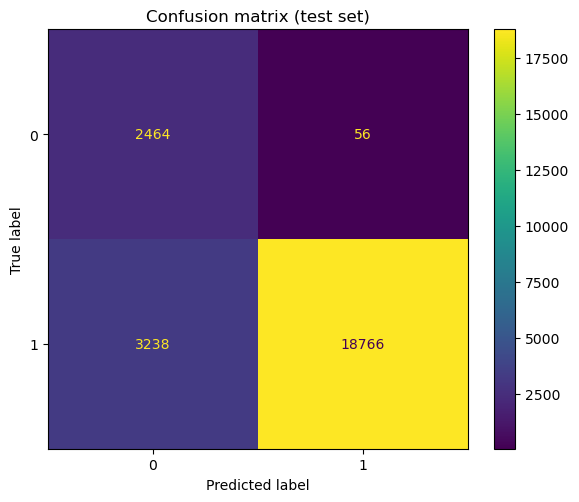

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

## 5. Churn probabilities for all customers → high_risk_customers.csv

Fit on full training data (or keep train/test split and score only a cohort). Here we score the full dataset for downstream segmentation and campaigns.

In [9]:
# Refit on full data for production-style scores (optional: keep holdout for validation only)
X_full = scaler.fit_transform(model_df[feature_cols])
model.fit(X_full, model_df["churn"])
all_prob = model.predict_proba(scaler.transform(model_df[feature_cols]))[:, 1]

risk_df = model_df[["customer_id"]].copy()
risk_df["churn_probability"] = all_prob
risk_df = risk_df.sort_values("churn_probability", ascending=False).reset_index(drop=True)

high_risk_path = OUT_DIR / "high_risk_customers.csv"
risk_df.to_csv(high_risk_path, index=False)
print(f"Saved {len(risk_df)} rows to {high_risk_path}")
risk_df.head(10)

Saved 98096 rows to ../outputs/high_risk_customers.csv


,customer_id,churn_probability
0,CUST1879,1.0
1,CUST2540,1.0
2,CUST2232,1.0
3,CUST2602,1.0
4,CUST1577,1.0
5,CUST2812,1.0
6,CUST2890,1.0
7,CUST1847,1.0
8,CUST1597,1.0
9,CUST2125,1.0
